In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
top20_deathtoll = pd.read_csv('top20_deathtoll.csv')

In [3]:
len(top20_deathtoll['Country_Other'])

20

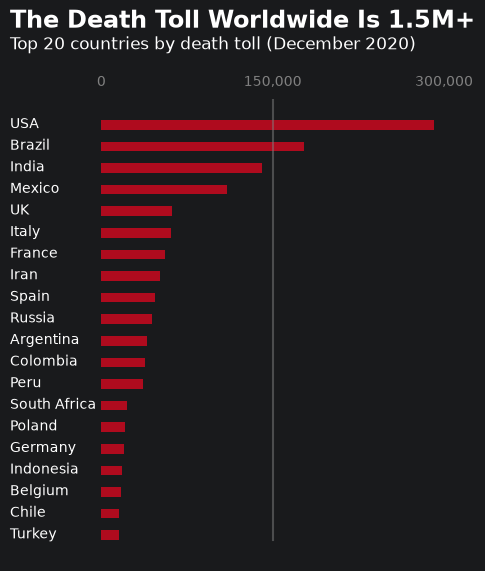

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

top20_deathtoll = pd.read_csv('top20_deathtoll.csv')

fig, ax = plt.subplots(figsize=(4.5, 6))
ax.barh(top20_deathtoll['Country_Other'],
        top20_deathtoll['Total_Deaths'],
        height=0.45, color='#af0b1e')

for location in ['left', 'right', 'top', 'bottom']:
    ax.spines[location].set_visible(False)

ax.set_xticks([0, 150000, 300000])

ax.xaxis.tick_top()

ax.tick_params(top=False, left=False)

ax.tick_params(axis='x', colors='grey')

ax.text(x=-80000, y=23.5,
        s='The Death Toll Worldwide Is 1.5M+',
        weight='bold', size=17)

ax.text(x=-80000, y=22.5,
        s='Top 20 countries by death toll (December 2020)',
        size=12)

ax.set_xticklabels(['0','150,000','300,000'])
ax.set_yticks([])

for i, country in zip(range(len(top20_deathtoll['Country_Other'])), top20_deathtoll['Country_Other']):
    ax.text(x=-80000, y=i-0.15, s=country)

ax.axvline(x=150000,ymin=0.045,c='grey',alpha=0.5)

plt.show()

In [5]:
death_toll = pd.read_csv('covid_avg_deaths.csv')
death_toll

,Month,New_deaths
0,1,0
1,2,0
2,3,77
3,4,1844
4,5,1448
5,6,785
6,7,769
7,8,1020
8,9,739
9,10,751


In [6]:
death_toll.iloc[0:3]

,Month,New_deaths
0,1,0
1,2,0
2,3,77


In [7]:
death_toll.iloc[3:6]

,Month,New_deaths
3,4,1844
4,5,1448
5,6,785


In [8]:
death_toll.iloc[6:9]

,Month,New_deaths
6,7,769
7,8,1020
8,9,739


In [9]:
death_toll.iloc[9:12]

,Month,New_deaths
9,10,751
10,11,1225
11,12,2247


In [10]:
death_toll.iloc[np.split(np.array(death_toll['Month']),4)[0]]

,Month,New_deaths
1,2,0
2,3,77
3,4,1844


In [11]:
death_toll['Month'].iloc[np.split(np.array(death_toll['Month']),4)[0]]

1    2
2    3
3    4
Name: Month, dtype: int64

In [12]:
split = np.split(np.array(death_toll['Month'])-1,4)
quarter = ['Jan - Mar','Mar - Jun','Jun - Oct','Oct - Dec']
x_coord = [1.1,3.7,7.1,10.5]
y_coord = [-300,800,500,600]
rotation = [3,0,0,45]
axs = list(range(4))

interval_new = {}

for i in axs:
    interval_new[i] = []
    interval_new[i].append(split[i])
    interval_new[i].append(quarter[i])
    interval_new[i].append(x_coord[i])
    interval_new[i].append(y_coord[i])
    interval_new[i].append(rotation[i])

interval_new

{0: [array([0, 1, 2]), 'Jan - Mar', 1.1, -300, 3],
 1: [array([3, 4, 5]), 'Mar - Jun', 3.7, 800, 0],
 2: [array([6, 7, 8]), 'Jun - Oct', 7.1, 500, 0],
 3: [array([ 9, 10, 11]), 'Oct - Dec', 10.5, 600, 45]}

In [18]:
deaths = [2387,126203,227178,295406]
proportions = [round(i/295406,2) for i in deaths]
xmax_values = [round(0.5 + i * .3,3) for i in proportions]

In [22]:
for i in interval_new.keys():
    interval_new[i].append(xmax_values[i])


In [26]:
for i in interval_new.keys():
    interval_new[i].append(deaths[i])

In [27]:
interval_new

{0: [array([0, 1, 2]), 'Jan - Mar', 1.1, -300, 3, 0.503, 2387],
 1: [array([3, 4, 5]), 'Mar - Jun', 3.7, 800, 0, 0.629, 126203],
 2: [array([6, 7, 8]), 'Jun - Oct', 7.1, 500, 0, 0.731, 227178],
 3: [array([ 9, 10, 11]), 'Oct - Dec', 10.5, 600, 45, 0.8, 295406]}

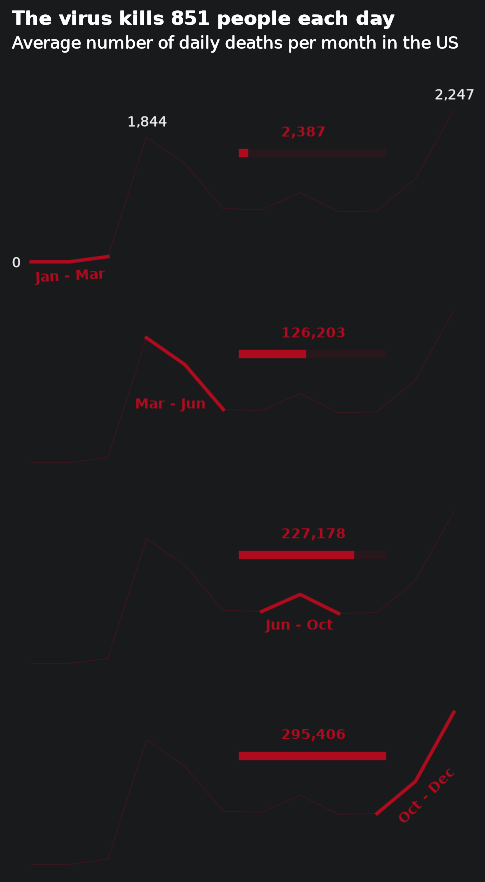

In [28]:
fig, axes = plt.subplots(nrows=4,ncols=1,figsize=(6,10))

for idx, val in interval_new.items():
    for location in ['left', 'right', 'top', 'bottom']:
        axes[idx].spines[location].set_visible(False)
    axes[idx].set_xticklabels([])
    axes[idx].set_yticklabels([])
    axes[0].text(0.5,-80,'0',alpha=0.5)
    axes[0].text(3.5,2000,'1,844',alpha=0.5)
    axes[0].text(11.5,2400,'2,247',alpha=0.5)
    axes[0].text(0.5,3500,s='The virus kills 851 people each day',weight='bold', size=14)
    axes[0].text(0.5,3150,s='Average number of daily deaths per month in the US', size=12)

    # axes[0].axhline(y=1600,xmin=0.5,xmax=0.8,linewidth=6,color='#af0b1e',alpha=0.1)

    axes[idx].plot(death_toll['Month'],death_toll['New_deaths'],color='#af0b1e', linewidth=0.5,alpha=0.3)
    axes[idx].plot(death_toll['Month'].iloc[val[0]],death_toll['New_deaths'].iloc[val[0]],color='#af0b1e',linewidth=2.5)
    axes[idx].tick_params(left=False, bottom=False)
    axes[idx].text(val[2],val[3],val[1],color='#af0b1e',weight='bold',rotation=val[4])

    axes[idx].axhline(y=1600,xmin=0.5,xmax=0.8,linewidth=6,color='#af0b1e',alpha=0.1)
    axes[idx].axhline(y=1600,xmin=0.5,xmax=val[5],linewidth=6,color='#af0b1e')
    # axes[1].axhline(y=1600,xmin=0.5,xmax=0.8,linewidth=6,color='#af0b1e',alpha=0.1)
    # axes[2].axhline(y=1600,xmin=0.5,xmax=0.8,linewidth=6,color='#af0b1e',alpha=0.1)
    # axes[3].axhline(y=1600,xmin=0.5,xmax=0.8,linewidth=6,color='#af0b1e',alpha=0.1)
    axes[idx].text(7.5,1850,s=format(val[6],","),color='#af0b1e',weight='bold')

plt.show()

In [14]:
interval = dict(zip( range(4), np.split(np.array(death_toll['Month'])-1,4) ))
interval

{0: array([0, 1, 2]),
 1: array([3, 4, 5]),
 2: array([6, 7, 8]),
 3: array([ 9, 10, 11])}

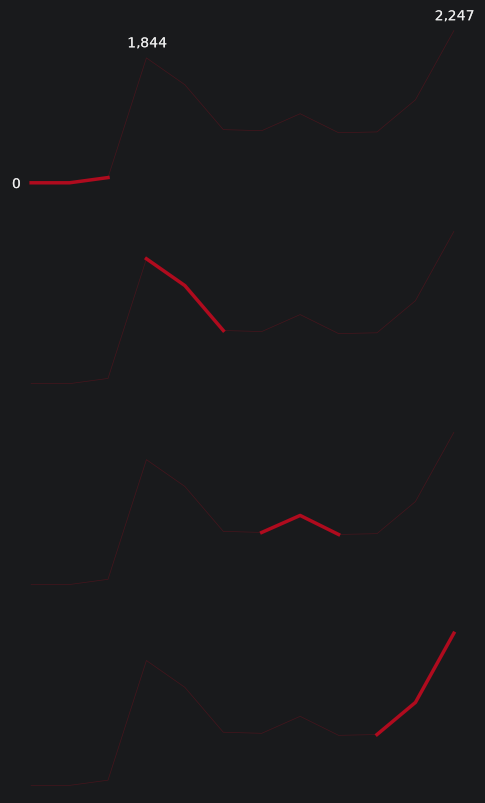

In [15]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(6, 10))

for idx, lst in interval.items():
    for location in ['left', 'right', 'top', 'bottom']:
        axes[idx].spines[location].set_visible(False)
    axes[0].text(0.5,-80,'0',alpha=0.5)
    axes[0].text(3.5,2000,'1,844',alpha=0.5)
    axes[0].text(11.5,2400,'2,247',alpha=0.5)
    axes[idx].plot(death_toll['Month'].iloc[lst],death_toll['New_deaths'].iloc[lst],color='#af0b1e', linewidth=2.5)
    axes[idx].plot(death_toll['Month'],death_toll['New_deaths'],color='#af0b1e',linewidth=0.5,alpha=0.3)
    axes[idx].set_xticklabels([])
    axes[idx].set_yticklabels([])
    axes[idx].tick_params(left=False, bottom=False)


plt.show()

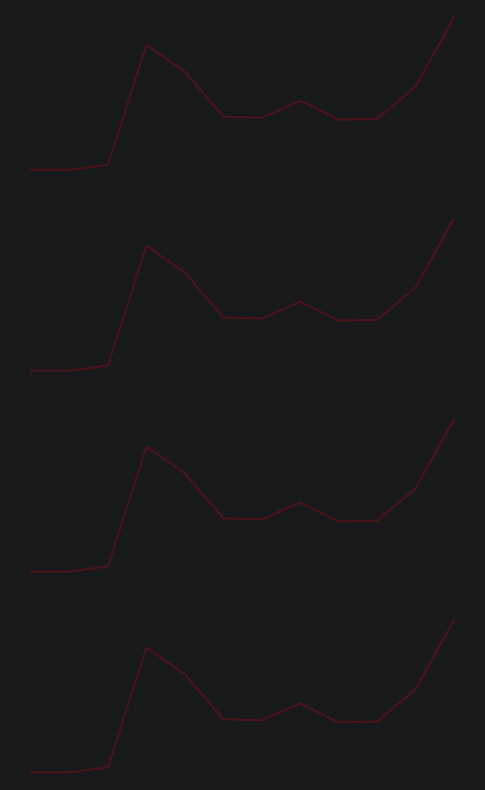

In [16]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(6,10))



for i in range(4):
    for location in ['left', 'right', 'top', 'bottom']:
        ax[i].spines[location].set_visible(False)
        ax[i].set_yticklabels([])
        ax[i].set_xticklabels([])
        ax[i].tick_params(left=False, bottom=False)
        ax[i].plot(death_toll['Month'],death_toll['New_deaths'],color='#af0b1e', alpha=0.1)



        # if location == 'left' or location == 'bottom':
        #     ax[i].tick_params(left=False, bottom=False)

# ax.text(x=-80000, y=23.5,s='The virus kills 851 people each day',weight='bold', size=17)
# ax.text(x=-80000, y=22.5,s='Average number of daily deaths per month in the US',size=15)


plt.show()

